In [15]:
import numpy as np

In [16]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [17]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ensemble_learning"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=500, noise=0.3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons,
                                                    test_size=0.2,
                                                    random_state=42)
 

In [19]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


log_clf = LogisticRegression(random_state=42)
rnd_clf = RandomForestClassifier(random_state=42)
svm_clf = SVC(random_state=42)

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf),('svc', svm_clf)], voting='hard'
)
voting_clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [20]:
from sklearn.metrics import accuracy_score

for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    # y_pred = clf.score(X_test, y_test)
    y_pred = clf.predict(X_test)
    print(f"{clf.__class__.__name__}: {accuracy_score(y_test,y_pred)}")

LogisticRegression: 0.85
RandomForestClassifier: 0.88
SVC: 0.87
VotingClassifier: 0.87


In [21]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

voting_clf2 = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(random_state=42, probability=True))
    ], voting='soft'
)
voting_clf2.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [22]:


for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))
(f"Ensemble Model: {voting_clf.score(X_test,y_test)}")



lr = 0.856
rf = 0.904
svc = 0.88


'Ensemble Model: 0.88'

In [23]:
voting_clf.score(X_test, y_test)

0.88

In [24]:
for name, clf in voting_clf2.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))
(f"Ensemble Model 2: {voting_clf2.score(X_test,y_test)}")

lr = 0.864
rf = 0.896
svc = 0.896


'Ensemble Model 2: 0.92'

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# Create dataset
X, y = make_classification(n_samples=1000, n_features=10, 
                          n_informative=8, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create classifiers with probability estimates
clf1 = LogisticRegression(random_state=42, max_iter=1000)
clf2 = SVC(kernel='rbf', probability=True, random_state=42)
clf3 = DecisionTreeClassifier(max_depth=5, random_state=42)
clf4 = KNeighborsClassifier(n_neighbors=5)

# Hard voting
hard_voting = VotingClassifier(
    estimators=[('lr', clf1), ('svc', clf2), ('dt', clf3), ('knn', clf4)],
    voting='hard'
)

# Soft voting
soft_voting = VotingClassifier(
    estimators=[('lr', clf1), ('svc', clf2), ('dt', clf3), ('knn', clf4)],
    voting='soft'
)

# Train both
hard_voting.fit(X_train, y_train)
soft_voting.fit(X_train, y_train)

# Compare
hard_score = hard_voting.score(X_test, y_test)
soft_score = soft_voting.score(X_test, y_test)

print("=" * 60)
print("HARD vs SOFT VOTING COMPARISON")
print("=" * 60)
print(f"Hard Voting Accuracy: {hard_score:.4f}")
print(f"Soft Voting Accuracy: {soft_score:.4f}")
print(f"Improvement: {(soft_score - hard_score):.4f}")

HARD vs SOFT VOTING COMPARISON
Hard Voting Accuracy: 0.8750
Soft Voting Accuracy: 0.8800
Improvement: 0.0050



CASE STUDY: Single Prediction Where Soft Voting Excels
True class: 1

Individual Model Predictions and Probabilities:
------------------------------------------------------------
Logistic Regression  -> Class 0 | Probabilities: [0.683, 0.317]
SVC                  -> Class 1 | Probabilities: [0.024, 0.976]
Decision Tree        -> Class 1 | Probabilities: [0.000, 1.000]
KNN                  -> Class 1 | Probabilities: [0.000, 1.000]

------------------------------------------------------------
VOTING RESULTS:
Hard Voting: Class 1 (Votes: Class 0=1, Class 1=3)
Soft Voting: Class 1 (Avg Probabilities: Class 0=0.177, Class 1=0.823)

Actual Class: 1


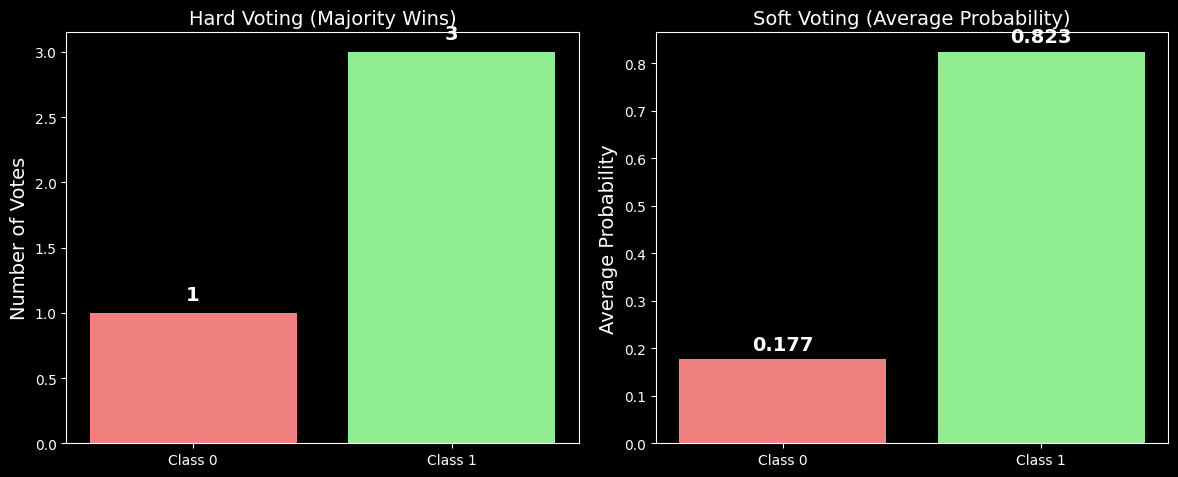

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


def demonstrate_soft_voting_advantage(X_train, X_test, y_train, y_test):
    """Show a case where soft voting can outperform hard voting"""

    # Train individual classifiers
    lr = LogisticRegression(random_state=42, max_iter=1000).fit(X_train, y_train)
    svc = SVC(kernel='rbf', probability=True, random_state=42).fit(X_train, y_train)
    dt = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)
    knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)

    models = {
        'Logistic Regression': lr,
        'SVC': svc,
        'Decision Tree': dt,
        'KNN': knn
    }

    # Find a test sample where models disagree
    sample_idx = None
    for i in range(len(X_test)):
        predictions = [model.predict(X_test[i:i+1])[0] for model in models.values()]
        if len(set(predictions)) > 1:
            sample_idx = i
            break

    if sample_idx is None:
        raise ValueError("No sample found where models disagree.")

    X_sample = X_test[sample_idx:sample_idx+1]
    y_true = y_test[sample_idx]

    print("\n" + "=" * 60)
    print("CASE STUDY: Single Prediction Where Soft Voting Excels")
    print("=" * 60)
    print(f"True class: {y_true}")
    print("\nIndividual Model Predictions and Probabilities:")
    print("-" * 60)

    hard_votes = {0: 0, 1: 0}
    soft_probs = {0: 0.0, 1: 0.0}

    for name, model in models.items():
        pred = model.predict(X_sample)[0]
        probs = model.predict_proba(X_sample)[0]

        hard_votes[pred] += 1
        soft_probs[0] += probs[0]
        soft_probs[1] += probs[1]

        print(f"{name:20} -> Class {pred} | Probabilities: [{probs[0]:.3f}, {probs[1]:.3f}]")

    # Average probabilities for soft voting
    soft_probs[0] /= len(models)
    soft_probs[1] /= len(models)

    hard_result = max(hard_votes, key=hard_votes.get)
    soft_result = np.argmax([soft_probs[0], soft_probs[1]])

    print("\n" + "-" * 60)
    print("VOTING RESULTS:")
    print(f"Hard Voting: Class {hard_result} "
          f"(Votes: Class 0={hard_votes[0]}, Class 1={hard_votes[1]})")
    print(f"Soft Voting: Class {soft_result} "
          f"(Avg Probabilities: Class 0={soft_probs[0]:.3f}, Class 1={soft_probs[1]:.3f})")
    print(f"\nActual Class: {y_true}")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    classes = ['Class 0', 'Class 1']
    colors = ['lightgreen' if i == y_true else 'lightcoral' for i in range(2)]

    # Hard voting
    votes = [hard_votes[0], hard_votes[1]]
    ax1.bar(classes, votes, color=colors)
    ax1.set_title('Hard Voting (Majority Wins)')
    ax1.set_ylabel('Number of Votes')

    for i, v in enumerate(votes):
        ax1.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

    # Soft voting
    probs = [soft_probs[0], soft_probs[1]]
    ax2.bar(classes, probs, color=colors)
    ax2.set_title('Soft Voting (Average Probability)')
    ax2.set_ylabel('Average Probability')

    for i, p in enumerate(probs):
        ax2.text(i, p + 0.02, f'{p:.3f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return hard_votes, soft_probs


# Example usage:
hard_votes, soft_probs = demonstrate_soft_voting_advantage(X_train, X_test, y_train, y_test)


MATHEMATICAL EXPLANATION

Scenario: 3 classifiers predicting a binary outcome

Hard Voting (1 vote per classifier):
  Classifier A: Class 1 (confidence: 0.51)
  Classifier B: Class 0 (confidence: 0.99)
  Classifier C: Class 0 (confidence: 0.99)
  Result: Class 0 wins (2 votes vs 1 vote)
  → Ignores confidence information

Soft Voting (Weighted by probabilities):
  Classifier A: P(Class 1)=0.51, P(Class 0)=0.49
  Classifier B: P(Class 1)=0.01, P(Class 0)=0.99
  Classifier C: P(Class 1)=0.01, P(Class 0)=0.99
  Average P(Class 1) = (0.51 + 0.01 + 0.01) / 3 = 0.177
  Average P(Class 0) = (0.49 + 0.99 + 0.99) / 3 = 0.823
  Result: Class 0 wins with much higher confidence!


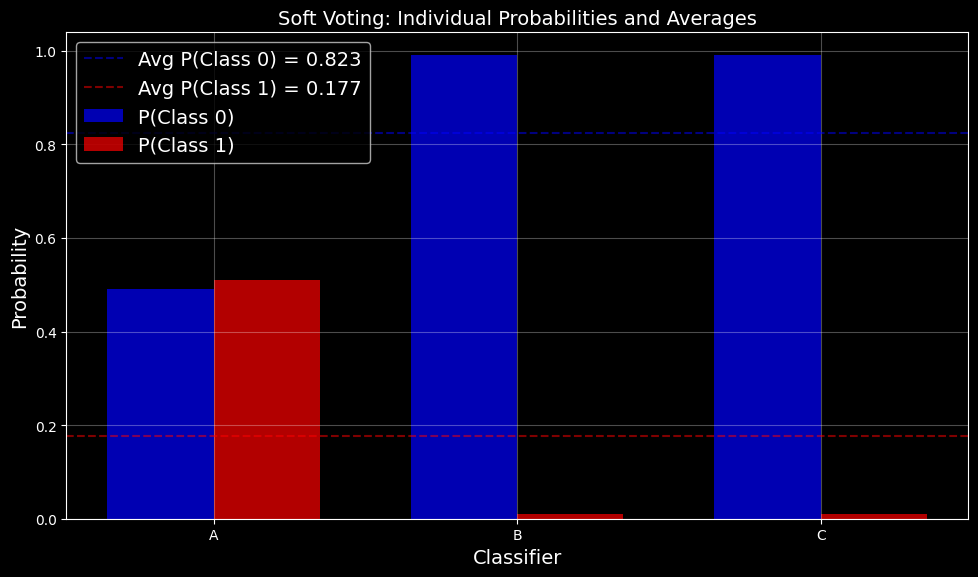

In [27]:
def soft_voting_explanation():
    """Mathematical explanation with concrete numbers"""
    
    print("\n" + "=" * 60)
    print("MATHEMATICAL EXPLANATION")
    print("=" * 60)
    
    # Example scenario
    print("\nScenario: 3 classifiers predicting a binary outcome")
    print("\nHard Voting (1 vote per classifier):")
    print("  Classifier A: Class 1 (confidence: 0.51)")
    print("  Classifier B: Class 0 (confidence: 0.99)")
    print("  Classifier C: Class 0 (confidence: 0.99)")
    print("  Result: Class 0 wins (2 votes vs 1 vote)")
    print("  → Ignores confidence information")
    
    print("\nSoft Voting (Weighted by probabilities):")
    print("  Classifier A: P(Class 1)=0.51, P(Class 0)=0.49")
    print("  Classifier B: P(Class 1)=0.01, P(Class 0)=0.99")
    print("  Classifier C: P(Class 1)=0.01, P(Class 0)=0.99")
    print("  Average P(Class 1) = (0.51 + 0.01 + 0.01) / 3 = 0.177")
    print("  Average P(Class 0) = (0.49 + 0.99 + 0.99) / 3 = 0.823")
    print("  Result: Class 0 wins with much higher confidence!")
    
    # Visual demonstration
    fig, ax = plt.subplots(figsize=(10, 6))
    
    classifiers = ['A', 'B', 'C']
    prob_class1 = [0.51, 0.01, 0.01]
    prob_class0 = [0.49, 0.99, 0.99]
    
    x = np.arange(len(classifiers))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, prob_class0, width, label='P(Class 0)', color='blue', alpha=0.7)
    bars2 = ax.bar(x + width/2, prob_class1, width, label='P(Class 1)', color='red', alpha=0.7)
    
    # Add average lines
    avg_class0 = np.mean(prob_class0)
    avg_class1 = np.mean(prob_class1)
    ax.axhline(y=avg_class0, color='blue', linestyle='--', alpha=0.5, 
               label=f'Avg P(Class 0) = {avg_class0:.3f}')
    ax.axhline(y=avg_class1, color='red', linestyle='--', alpha=0.5,
               label=f'Avg P(Class 1) = {avg_class1:.3f}')
    
    ax.set_xlabel('Classifier')
    ax.set_ylabel('Probability')
    ax.set_title('Soft Voting: Individual Probabilities and Averages')
    ax.set_xticks(x)
    ax.set_xticklabels(classifiers)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

soft_voting_explanation()

## Bagging and Pasting

> Scikit-Learn offers a simple API for both bagging and pasting with the BaggingClas
sifier class (or BaggingRegressor for regression). The following code trains an
ensemble of 500 Decision Tree classifiers, 5 each trained on 100 training instances ran‐
domly sampled from the training set with replacement (this is an example of bagging,
but if you want to use pasting instead, just set bootstrap=False). The n_jobs param‐
eter tells Scikit-Learn the number of CPU cores to use for training and predictions
(–1 tells Scikit-Learn to use all available cores)

In [28]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier  

# This is an example of Bagging, if bootstrap=False then it becomes Pasting
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500, max_samples=100, bootstrap=True, n_jobs=-1
)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.815

### Out-of-Bag Evaluation

> With bagging, some instances may be sampled several times for any given predictor,
while others may not be sampled at all. By default a BaggingClassifier samples m
training instances with replacement (bootstrap=True), where m is the size of the
training set. This means that only about 63% of the training instances are sampled on
average for each predictor.6 The remaining 37% of the training instances that are not
sampled are called out-of-bag (oob) instances. Note that they are not the same 37%
for all predictors.

In [29]:
bag_clf_oob = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500, max_samples=100, bootstrap=True, n_jobs=-1, oob_score=True,
)
bag_clf_oob.fit(X_train, y_train)
y_pred = bag_clf_oob.predict(X_test)
accuracy_score(y_test, y_pred)

0.805

In [30]:
bag_clf_oob.oob_score_

0.83875

In [31]:
bag_svc_clf = BaggingClassifier(
    SVC(), n_estimators=500, max_samples=100, bootstrap=True, n_jobs=-1
)
bag_svc_clf.fit(X_train, y_train)
pred =bag_svc_clf.predict(X_test)
accuracy_score(y_test, pred)

0.835

In [32]:
bag_svc_clf = BaggingClassifier(
    SVC(probability=True), n_estimators=500, max_samples=100, bootstrap=True, n_jobs=-1
)
bag_svc_clf.fit(X_train, y_train)
pred =bag_svc_clf.predict(X_test)
accuracy_score(y_test, pred)

0.825

## Random Patches and Random Subspaces

> The BaggingClassifier class supports sampling the features as well. This is con‐
trolled by two hyperparameters: max_features and bootstrap_features. They work
the same way as max_samples and bootstrap, but for feature sampling instead of
instance sampling. Thus, each predictor will be trained on a random subset of the
input features.

> This is useful when dealing with high-dimensional inputs such as Images. Sampling both training innstance and features is called the **Ranom Patches Method**

> Keeping all training instances (i.e., bootstrap=False and max_sam
ples=1.0) but sampling features (i.e., bootstrap_features=True and/or max_fea
tures smaller than 1.0) is called the **Random Subspaces method**


## Feature Importance

In [33]:
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,parser='auto')
rnd_mnst_clf =  RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rnd_mnst_clf.fit(X_mnist, y_mnist)

heatmap_image = rnd_mnst_clf.feature_importances_.reshape(28,28)


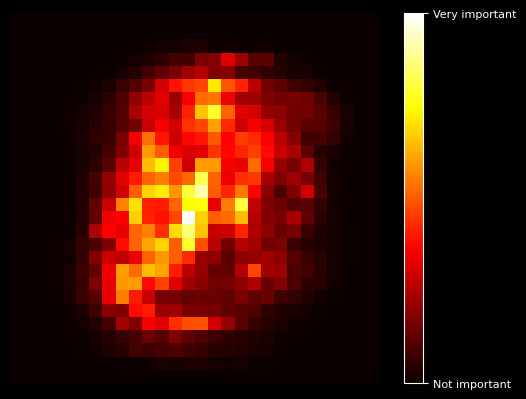

In [34]:
import matplotlib.pyplot as plt
img = plt.imshow(heatmap_image, cmap="hot")
# cbar = plt.colorbar(img)

cbar = plt.colorbar(ticks=[rnd_mnst_clf.feature_importances_.min(),
                           rnd_mnst_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Not important', 'Very important'], fontsize=8)
plt.axis("off")
plt.show()

# Boosting

### Ada-Boosting

In [35]:
def plot_decision_boundary(clf, X, y, alpha=1.0):
    axes=[-1.5, 2.4, -1, 1.5]
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    plt.contourf(x1, x2, y_pred, alpha=0.3 * alpha, cmap='Wistia')
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8 * alpha)
    colors = ["#78785c", "#c47b27"]
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

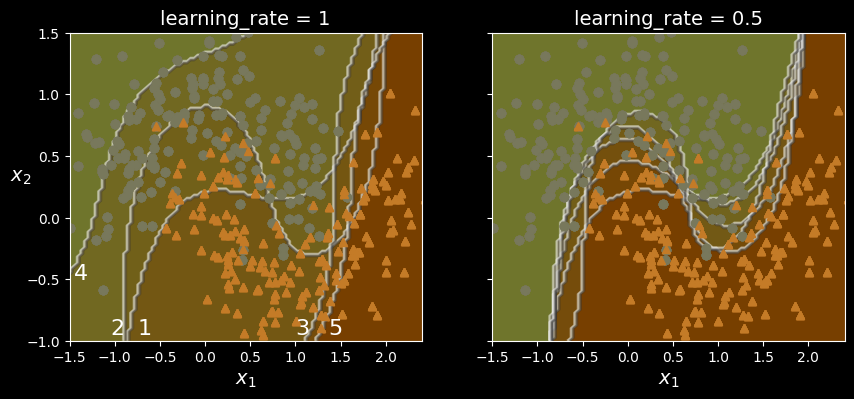

In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

m = len(X_train)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
for subplot, learning_rate in ((0, 1), (1, 0.5)):
    sample_weights = np.ones(m) / m
    plt.sca(axes[subplot])
    for i in range(5):
        svm_clf = SVC(C=0.2, gamma=0.6, random_state=42)
        svm_clf.fit(X_train, y_train, sample_weight=sample_weights * m)
        y_pred = svm_clf.predict(X_train)

        # Step 2 - Add the weights of all misclassified samples. i.e calculate the weighted error
        error_weights = sample_weights[y_pred != y_train].sum()
        r = error_weights / sample_weights.sum()  # equation 7-1
        # Step 3 — Compute Learner Weight (α)
        # Important Intuition
        # The better the learner:
        # the larger the α
        # The worse the learner:
        # the smaller the α
        alpha = learning_rate * np.log((1 - r) / r)  # equation 7-2
        # Misclassified samples get multiplied by:
        # e^a
        # So: larger alpha more aggressive reweighting.
        # Meaning: strong learners force AdaBoost to focus harder on mistakes.
        sample_weights[y_pred != y_train] *= np.exp(alpha)  # equation 7-3
        # normalization step indirectly decreases them relatively
        sample_weights /= sample_weights.sum()  # normalization step

        plot_decision_boundary(svm_clf, X_train, y_train, alpha=0.4)
        plt.title(f"learning_rate = {learning_rate}")
    if subplot == 0:
        plt.text(-0.75, -0.95, "1", fontsize=16)
        plt.text(-1.05, -0.95, "2", fontsize=16)
        plt.text(1.0, -0.95, "3", fontsize=16)
        plt.text(-1.45, -0.5, "4", fontsize=16)
        plt.text(1.36,  -0.95, "5", fontsize=16)
    else:
        plt.ylabel("")


plt.show()

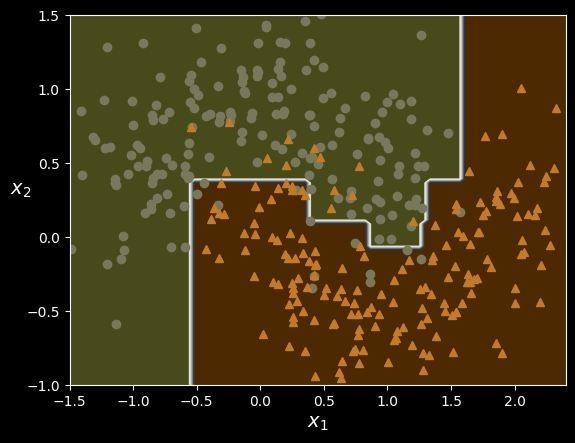

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=200, learning_rate=0.5
)
ada_clf.fit(X_train, y_train)
plot_decision_boundary(ada_clf, X_train, y_train)
# If your AdaBoost ensemble is overfitting the training set, you can
# try reducing the number of estimators or more strongly regulariz‐
# ing the base estimator